In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sqlalchemy import create_engine, text

DB_USER = 'postgres'
DB_PASSWORD = 'milan'
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'taxi_nyc_db'
TABLE_NAME = 'taxi_nyc'

DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

df = pd.read_csv('train.csv')
print(f"Dataset caricato con {df.shape[0]} righe e {df.shape[1]} colonne") 

print("Stiamo caricando il dataset su PostgreSQL...")
df.to_sql(TABLE_NAME, engine, if_exists = 'replace', index = False)

print(f"Caricato correttamente nella tabella: {TABLE_NAME}")

Dataset caricato con 1458644 righe e 11 colonne
Stiamo caricando il dataset su PostgreSQL...
Caricato correttamente nella tabella: taxi_nyc


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [4]:
print(f"I valori nulli nel dataset sono:\n{df.isnull().sum()}")

I valori nulli nel dataset sono:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [5]:
print(f"I duplicati all'interno del dataset sono:\n{df.duplicated().sum()}")

I duplicati all'interno del dataset sono:
0


In [6]:
print(f"Il dataset è composto da: {df.shape[0]} righe e {df.shape[1]} colonne")
print(f"Le colonne del dataset sono:\n{df.columns.tolist()}")

Il dataset è composto da: 1458644 righe e 11 colonne
Le colonne del dataset sono:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


In [7]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

#Creiamoci: mese, giorno, ora e minuto e se appartiene al fine settimana etc...

df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_weekday'] = df['pickup_datetime'].dt.dayofweek #Valore compreso tra 0-6
df['is_weekend'] = df['pickup_weekday'].isin([5, 6]).astype(int)

df['dropoff_month'] = df['dropoff_datetime'].dt.month
df['dropoff_day'] = df['dropoff_datetime'].dt.day
df['dropoff_hour'] = df['dropoff_datetime'].dt.hour
df['dropoff_weekday'] = df['dropoff_datetime'].dt.dayofweek #Valore compreso tra 0-6
df['dropoff_weekend'] = df['dropoff_weekday'].isin([5, 6]).astype(int)

df['duration_trip_calc'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds()

df[['duration_trip_calc', 'trip_duration']].head()

,duration_trip_calc,trip_duration
0,455.0,455
1,663.0,663
2,2124.0,2124
3,429.0,429
4,435.0,435


In [8]:
df.describe()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_month,pickup_day,pickup_hour,pickup_weekday,is_weekend,dropoff_month,dropoff_day,dropoff_hour,dropoff_weekday,dropoff_weekend,duration_trip_calc
count,1.458644e+06,1458644,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,2016-04-01 10:10:24.940037120,2016-04-01 10:26:24.432310528,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02,3.516818e+00,1.550402e+01,1.360648e+01,3.050375e+00,2.853568e-01,3.517178e+00,1.550448e+01,1.359890e+01,3.054422e+00,2.866539e-01,9.594923e+02
min,1.000000e+00,2016-01-01 00:00:17,2016-01-01 00:03:31,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.000000e+00,2016-02-17 16:46:04.249999872,2016-02-17 17:05:32.500000,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02,2.000000e+00,8.000000e+00,9.000000e+00,1.000000e+00,0.000000e+00,2.000000e+00,8.000000e+00,9.000000e+00,1.000000e+00,0.000000e+00,3.970000e+02
50%,2.000000e+00,2016-04-01 17:19:40,2016-04-01 17:35:12,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02,4.000000e+00,1.500000e+01,1.400000e+01,3.000000e+00,0.000000e+00,4.000000e+00,1.500000e+01,1.400000e+01,3.000000e+00,0.000000e+00,6.620000e+02
75%,2.000000e+00,2016-05-15 03:56:08.750000128,2016-05-15 04:10:51.750000128,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03,5.000000e+00,2.300000e+01,1.900000e+01,5.000000e+00,1.000000e+00,5.000000e+00,2.300000e+01,1.900000e+01,5.000000e+00,1.000000e+00,1.075000e+03
max,2.000000e+00,2016-06-30 23:59:39,2016-07-01 23:02:03,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06,6.000000e+00,3.100000e+01,2.300000e+01,6.000000e+00,1.000000e+00,7.000000e+00,3.100000e+01,2.300000e+01,6.000000e+00,1.000000e+00,3.526282e+06
std,4.987772e-01,NaN,NaN,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03,1.681038e+00,8.703135e+00,6.399693e+00,1.954039e+00,4.515844e-01,1.681217e+00,8.703123e+00,6.483682e+00,1.956599e+00,4.521986e-01,5.237432e+03


In [9]:
def day_week(day):
    if day == 0:
        return 'Monday'
    elif day == 1:
        return 'Tuesday'
    elif day == 2:
        return 'Wednesday'
    elif day == 3:
        return 'Thursday'
    elif day == 4:
        return 'Friday'
    elif day == 5:
        return 'Saturday'
    else:
        return 'Sunday'

df['day_of_the_week'] = df['pickup_weekday'].apply(day_week)

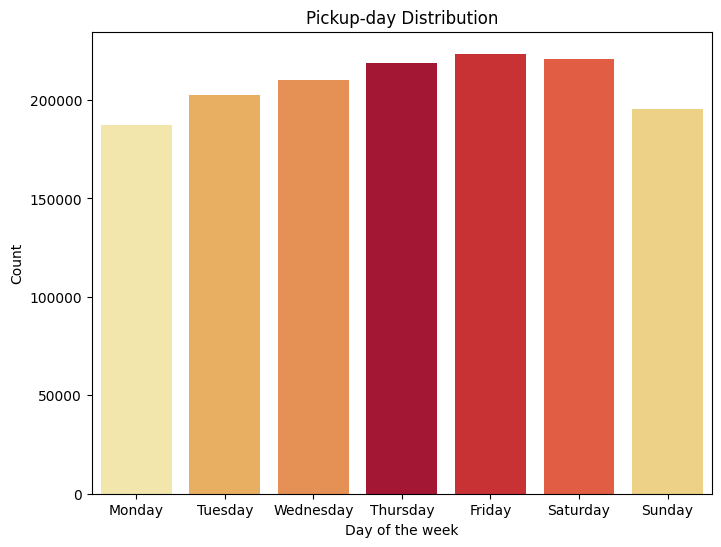

In [19]:
#Pickupday Distribution
plt.figure(figsize = (8, 6))
sns.countplot(data = df, x = 'day_of_the_week', order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
             palette = 'YlOrRd', hue = 'day_of_the_week')
plt.xlabel('Day of the week')
plt.ylabel('Count')
plt.title('Pickup-day Distribution')
plt.show()

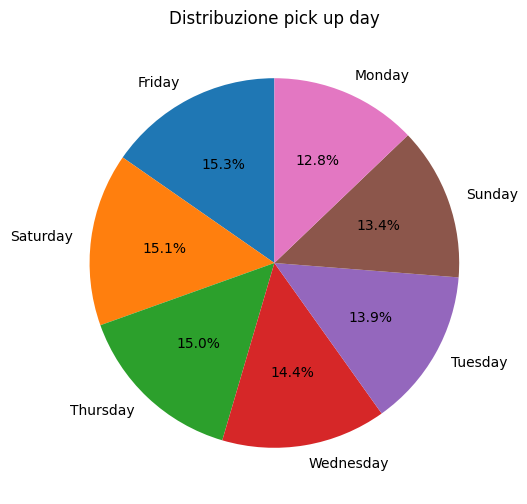

In [11]:
day_counts = df['day_of_the_week'].value_counts()
plt.figure(figsize = (8, 6))
plt.pie(day_counts, labels = day_counts.index, autopct = '%1.1f%%', startangle = 90)
plt.title('Distribuzione pick up day')
plt.show()

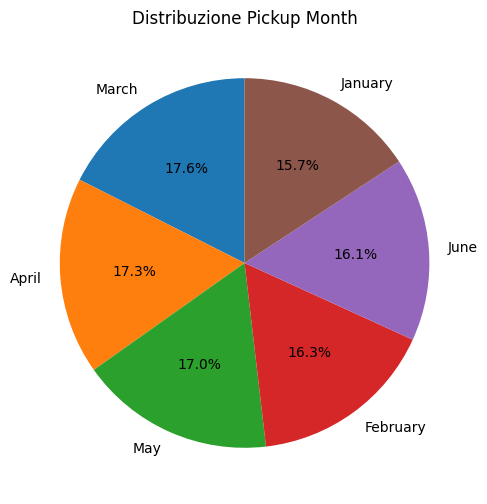

In [12]:
def month_name(month):
    if month == 1:
        return 'January'
    elif month == 2:
        return 'February'
    elif month == 3:
        return 'March'
    elif month == 4:
        return 'April'
    elif month == 5:
        return 'May'
    else:
        return 'June'

df['month_name'] = df['pickup_month'].apply(month_name)

month_counts = df['month_name'].value_counts()
plt.figure(figsize = (8, 6))
plt.pie(month_counts, labels = month_counts.index, autopct = '%1.1f%%', startangle = 90)
plt.title('Distribuzione Pickup Month')
plt.show()

In [21]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c  # distance in km

df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

df['speed'] = df['distance_km'] / (df['trip_duration'] / 3600)

In [23]:
df_clean = df[
    (df['speed'] > 0) & (df['speed'] < 100) &
    (df['trip_duration'] > 60) & (df['trip_duration'] < 7200) &
    (df['distance_km'] > 0.1) & (df['distance_km'] < 100) &
    (df['passenger_count'] != 0)
]
df_clean['trip_duration_min'] = df_clean['trip_duration'] / 60

print(f'Siamo partiti da un dataset iniziale di {df.shape[0]} righe e {df.shape[1]} colonne')
print(f'Adesso abbiamo un dataset con {df_clean.shape[0]} righe e {df.shape[1]} colonne')
print(f"E' stato rimosso il {100 - (len(df_clean)/ len(df)) * 100:.2f}% del dataset iniziale")

Siamo partiti da un dataset iniziale di 1458644 righe e 26 colonne
Adesso abbiamo un dataset con 1440078 righe e 26 colonne
E' stato rimosso il 1.27% del dataset iniziale


C:\Users\nicol\AppData\Local\Temp\ipykernel_8720\2513956853.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['trip_duration_min'] = df_clean['trip_duration'] / 60


In [25]:
df_clean.to_sql(
    name = "taxi_nyc_clean",
    con = engine,
    if_exists = "replace",  # overwrites if you re-run the cleaning
    index = False,
    chunksize = 10000
)
print("✅ Clean data loaded into table: taxi_nyc_clean")

✅ Clean data loaded into table: taxi_nyc_clean
